# 00 · Setup and environment check

**Run this notebook before the tutorial.** It is a pass/fail check. If the last cell draws a curve
with a sharp dip near 7.2 GHz, you are ready.

Any Jupyter environment works: JupyterLab, VS Code, or Google Colab.

- **Local:** `pip install "qprogram[viz]" scipy` (Python 3.11 to 3.14), then run the cells below.
- **Colab:** run the cells top to bottom. The second one installs what is missing.

Nothing here talks to hardware. QProgram ships a pure-Python reference platform, so every
experiment in this tutorial runs on your laptop.

## What we will do today

The tutorial follows the order a real qubit gets brought up, and each experiment introduces the
QProgram feature it needs:

- Find the **readout resonator** with a frequency sweep, then find the **qubit** with a second
  tone. That gets you buses, waveforms, sweeps, averaging, and results.
- Drive the qubit and calibrate a **pi pulse** from a Rabi curve.
- Measure **T1**, **T2\***, and **T2** with echo, using reusable pulse fragments.
- Read out **single shots**, set a threshold, and do **active reset** with real feedback.
- Take the same program to a different rack: **capability checks**, execution plans, and the
  real-time versus host-side split.
- **Extend the language** with your own waveform, sweep source, and vendor operation, then ship the
  result as a text file another lab can load.

By the end you will have a calibration set for a simulated qubit, and the programs that produced
it, in files you could hand to someone else.

### Check 1: Python version

QProgram is pure Python and needs 3.11 or newer. It is tested on 3.11 through 3.14.

In [1]:
import sys

version = ".".join(str(v) for v in sys.version_info[:3])
if (3, 11) <= sys.version_info[:2] <= (3, 14):
    print(f"OK: Python {version} is supported.")
else:
    print(f"Python {version} is outside the tested range (3.11 to 3.14).")
    print("- On Google Colab: Runtime > Change runtime type, then pick a supported version.")
    print("- Locally: create a fresh environment, for example `uv venv --python 3.13`.")

OK: Python 3.13.12 is supported.


### Check 2: install QProgram

The cell below does nothing if QProgram is already installed, and installs it otherwise (a fresh
Colab runtime, for example). The `viz` extra pulls in matplotlib, which the notebooks use for
plots. `scipy` is not a QProgram dependency: the tutorial uses it to fit the curves you measure.

In [2]:
# Run me first. A no-op when qprogram is already installed, an install when it is not
# (a fresh Google Colab runtime, for example).
try:
    import qprogram  # noqa: F401
except ImportError:
    import subprocess
    import sys

    subprocess.run(
        [sys.executable, "-m", "pip", "install", "qprogram[viz]==0.1.0", "scipy"],
        check=True,
    )
    import qprogram  # noqa: F401

from importlib.metadata import version

print("qprogram", version("qprogram"))

qprogram 0.1.0


### Check 3: build a program

This is the smallest experiment that does something useful: sweep the readout frequency and record
what comes back. It is resonator spectroscopy, the first measurement on a new chip.

Five names, one line each:

- `BusSchema.transmon()` describes the chip layout. Each qubit has a `drive` line and a `readout`
  line, and the readout line has an ADC.
- `QProgram` is the builder. Every method call appends a node to a tree.
- `program.variable(...)` declares the swept parameter.
- `average` and `sweep` are context managers that nest, so the `with` statements are the loops.
- `measure` returns a handle you use later to pull the data out.

In [3]:
import qprogram as qp
from qprogram.buses import BusSchema

schema = BusSchema.transmon()
q = schema.q

program = qp.QProgram(label="resonator_spectroscopy", schema=schema)
ro_freq = program.variable("ro_freq", label="Readout frequency", units="Hz")

with program.average(shots=100):
    with program.sweep(ro_freq, qp.Linspace(7.15e9, 7.25e9, 81)):
        program.set_frequency(q[0].readout, ro_freq)
        m0 = program.measure(q[0].readout, "readout", "weights")

print("buses touched:", sorted(program.buses))
print("measurement handle:", m0.name)

buses touched: ['q0/readout']
measurement handle: q0/readout/m0


### Check 4: read the program back as text

A QProgram is data, not a script, so it serializes. `qp.dumps` writes the `.qp` text format: one
statement per line, indentation for nesting, no hidden state. This is the file you commit next to
your results.

In [4]:
print(qp.dumps(program))

#!QProgram 1.0

metadata:
  label: "resonator_spectroscopy"

schema:
  element q:
    drive info=IQ
    readout info=IQ+acquires

body:
  var ro_freq label="Readout frequency" units="Hz"

  average 100:
    for ro_freq in Linspace(start=7150000000.0, stop=7250000000.0, num=81):
      set_frequency q[0].readout ro_freq
      measure q[0].readout "readout" "weights" name="q0/readout/m0"



### Check 5: run it

`qp.simulate` runs the program on the reference platform, a pure-Python interpreter that ships
inside QProgram. It does not model pulses or timing. What it does model is the shape of the
experiment: the loops, the averaging, and one measurement record per `measure` call.

Where the numbers come from is up to you. A `MeasurementModel` is asked for one sample per shot,
and it receives `env`, a dict of the loop variables currently bound. Here the response is a
resonator dip: a Lorentzian centered at 7.2 GHz, 1.5 MHz wide, with a little noise on top.

In [5]:
import numpy as np

F_RESONATOR = 7.20e9  # Hz, where the dip should land
KAPPA = 1.5e6  # Hz, the resonator linewidth


def transmission(bus, env):
    """Complex transmission through the readout line at the frequency currently being swept."""
    detuning = (env["ro_freq"] - F_RESONATOR) / (KAPPA / 2)
    return 1.0 - 0.9 / (1.0 + 1j * detuning)


model = qp.MockMeasurementModel(response=transmission, noise=0.01, seed=4)
result = qp.simulate(program, model=model)

data = result.get(m0)
print("dims:", data.dims, "shape:", data.shape)

dims: ('ro_freq', 'IQ') shape: (81, 2)


The result is an `xarray.DataArray`. Its dimensions are named after your loop variables, so the
sweep you wrote is the axis you index. `IQ` is the extra axis every integrated measurement carries.

In [6]:
freqs = data.coords["ro_freq"].values
magnitude = np.abs(data.sel(IQ="I").values + 1j * data.sel(IQ="Q").values)

print("lowest transmission at:", freqs[magnitude.argmin()] / 1e9, "GHz")
print("expected:", F_RESONATOR / 1e9, "GHz")

lowest transmission at: 7.2 GHz
expected: 7.2 GHz


### Check 6: plotting

Several parts of the tutorial draw figures, so the last check is matplotlib. If you see a curve
with a dip in it, plotting works.

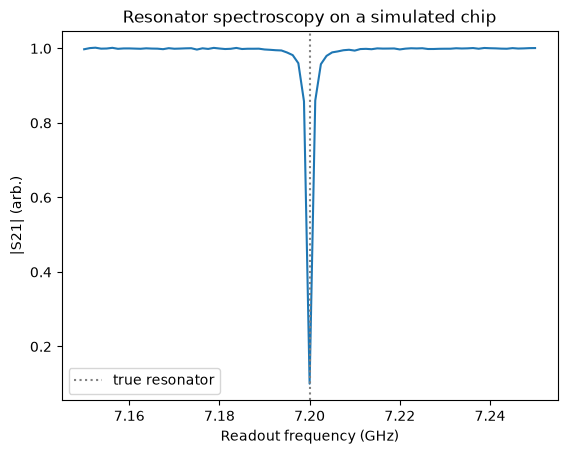

In [7]:
import matplotlib.pyplot as plt

plt.plot(freqs / 1e9, magnitude)
plt.axvline(F_RESONATOR / 1e9, color="grey", linestyle=":", label="true resonator")
plt.xlabel("Readout frequency (GHz)")
plt.ylabel("|S21| (arb.)")
plt.title("Resonator spectroscopy on a simulated chip")
plt.legend()
plt.show()

A curve with a dip near 7.2 GHz means the whole stack works: build, serialize, run, plot. ✅
See you at the tutorial.

Curious already? Change `shots=100` to `shots=2` in Check 3 and rerun the last four cells. The dip
is still there, but the noise makes the minimum jump around by a megahertz or two. Every number in
this tutorial is an average over a finite number of shots, and the shot count is the knob that
trades measurement time for precision. You will spend it carefully in Part 2.